In [2]:
import pandas as pd
df = pd.read_csv("german.csv",sep=';')

In [3]:
print(df.shape)
print(df.columns)
print(df.info())

(1000, 21)
Index(['Creditability', 'Account_Balance', 'Duration_of_Credit_monthly',
       'Payment_Status_of_Previous_Credit', 'Purpose', 'Credit_Amount',
       'Value_Savings_Stocks', 'Length_of_current_employment',
       'Instalment_per_cent', 'Sex_Marital_Status', 'Guarantors',
       'Duration_in_Current_address', 'Most_valuable_available_asset',
       'Age_years', 'Concurrent_Credits', 'Type_of_apartment',
       'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
       'Telephone', 'Foreign_Worker'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Creditability                      1000 non-null   int64
 1   Account_Balance                    1000 non-null   int64
 2   Duration_of_Credit_monthly         1000 non-null   int64
 3   Payment_Status_of_Previous_C

## 🧠 Important Principle

Just because a variable has **few unique values** does NOT automatically make it categorical.

That’s a beginner trap.

---

## 🔍 Let’s Analyze `No_of_dependents`

You said:

> It has values 1 and 2 only → so categorical.

But think deeper:

Does “2 dependents” represent a *category label*?
Or does it represent a **count**?

It represents a count.

And counts are numeric.

Even if the dataset only contains 1 and 2, conceptually it could have been 0, 3, 4 etc.

The dataset just doesn’t include them.

So structurally:

`No_of_dependents` = discrete numeric variable.

---

## 📌 Professional Rule

A feature is categorical when:

* The numbers are just codes
* There is no numeric distance meaning

Example:

`Account_Balance = 1,2,3,4`

Here:
4 is NOT “twice” 2.
These are categories encoded as integers.

That must be treated as categorical.

---

But:

`Age_years = 25, 40, 60`
There is natural order and distance.

`No_of_dependents = 1, 2`
There is order and meaning.
2 dependents > 1 dependent.

So logistic regression interpreting it linearly is reasonable.

---

## 🎯 Final Correct Classification

### True Numerical:

* Duration_of_Credit_monthly
* Credit_Amount
* Age_years
* Instalment_per_cent
* No_of_Credits_at_this_Bank
* No_of_dependents

### Encoded Categorical:

* Account_Balance
* Payment_Status_of_Previous_Credit
* Purpose
* Value_Savings_Stocks
* Length_of_current_employment
* Sex_Marital_Status
* Guarantors
* Duration_in_Current_address
* Most_valuable_available_asset
* Concurrent_Credits
* Type_of_apartment
* Occupation
* Telephone
* Foreign_Worker

---

## 💼 Why This Matters

If you treat encoded categories as numeric:

Logistic regression assumes:

Category 4 > Category 3 > Category 2 > Category 1 in linear effect.

That may be completely wrong.

This is how silent modeling errors happen.

---

# Understand the Target

##  target column: Creditability

This dataset version encodes:

1 → Good credit

0 → Bad credit

But for risk modeling, we prefer:

1 → Default (Bad)

0 → Non-default (Good)

Why?

Because we usually model:

P(Default | X)

Not P(Good | X).

So first professional decision:

We will reverse the target.

In [4]:
df['default'] = 1 - df['Creditability']
df.drop(columns=['Creditability'],inplace=True) # inplace=true makes sure changes will happened directly on dataframe , no copy return 

# Class imblance 

In [5]:
df['default'].value_counts(normalize=True)

default
0    0.7
1    0.3
Name: proportion, dtype: float64

# 🧠 Now We Frame the Business Properly
| Reality     | Model Predicts Approve (0)  | Model Predicts Reject (1)           |
| ----------- | --------------------------- | ----------------------------------- |
| Good (0)    | ✅ Correct Approval          | ❌ False Positive (Lost Opportunity) |
| Default (1) | ❌ False Negative (Big Loss) | ✅ Correct Rejection                 |

Important:

False Negative = Approve defaulter

False Positive = Reject good customer

And we already agreed:

False Negative is much more expensive.

# 🎯 Now We Lock the Business Objective

Let’s assume:

Cost of approving defaulter = 10 units
Cost of rejecting good customer = 1 unit

Expected Cost =
(FN × 10) + (FP × 1)

This is what we will minimize.

Not accuracy.
Not just AUC.

But expected cost.

This is professional modeling.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Account_Balance                    1000 non-null   int64
 1   Duration_of_Credit_monthly         1000 non-null   int64
 2   Payment_Status_of_Previous_Credit  1000 non-null   int64
 3   Purpose                            1000 non-null   int64
 4   Credit_Amount                      1000 non-null   int64
 5   Value_Savings_Stocks               1000 non-null   int64
 6   Length_of_current_employment       1000 non-null   int64
 7   Instalment_per_cent                1000 non-null   int64
 8   Sex_Marital_Status                 1000 non-null   int64
 9   Guarantors                         1000 non-null   int64
 10  Duration_in_Current_address        1000 non-null   int64
 11  Most_valuable_available_asset      1000 non-null   int64
 12  Age_years            

In [7]:
df['No_of_dependents'].value_counts()

No_of_dependents
1    845
2    155
Name: count, dtype: int64

# What Does “Monotonic” Mean?

Monotonic is a fancy word.

Very simple meaning:

It moves in only ONE direction.

That’s it.

# 📈 Monotonic Increasing

As X increases
Y always increases

Example:

Years of experience → Salary
More experience → more salary
Never goes down.

That’s monotonic increasing.

# 📉 Monotonic Decreasing

As X increases
Y always decreases

Example:

Income → Default Risk

Higher income → lower risk
Never increases again.

That’s monotonic decreasing.

# 🧠 In Credit Risk Context

If Account Balance increases:

1 → 2 → 3 → 4

And default risk keeps decreasing smoothly

That is a monotonic decreasing relationship.

Risk(1) > Risk(2) > Risk(3) > Risk(4)

Always one direction.
No zigzag.

# Category effects are rarely evenly spaced.

Example:

Maybe:

No account → extremely risky

Low balance → still risky

Medium balance → safe

High balance → slightly safer

The jump from 1→2 might be huge.
The jump from 3→4 might be tiny.

One-hot encoding captures that.

Numeric encoding forces smooth slope.

# 💼 Interview-Level Answer

If interviewer asks:

Why one-hot encode ordinal-like categories?

You say:

Treating encoded categories as numeric imposes a linear spacing assumption on log-odds. One-hot encoding removes that structural constraint and allows category-specific risk estimation.


# We are explaining:

> Why
> Balance_1 + Balance_2 + Balance_3 + Balance_4 = 1
> creates perfect multicollinearity
> and why this is called Dummy Variable Trap.

Deep breath. Let’s go step-by-step.

---

# 🧠 Step 1 — What Happens in One-Hot Encoding?

Suppose Account Balance has 4 categories:

1
2
3
4

After one-hot encoding, we create 4 columns:

| Person | B1 | B2 | B3 | B4 |
| ------ | -- | -- | -- | -- |
| A (1)  | 1  | 0  | 0  | 0  |
| B (2)  | 0  | 1  | 0  | 0  |
| C (3)  | 0  | 0  | 1  | 0  |
| D (4)  | 0  | 0  | 0  | 1  |

Now notice something VERY IMPORTANT:

For every row:

B1 + B2 + B3 + B4 = 1

Always.

No exception.

---

# 🧠 Step 2 — Why Is This Dangerous?

Because one column can be written using the others.

Example:

B4 = 1 − (B1 + B2 + B3)

That means:

B4 is NOT independent.

It is fully determined by the other three.

That means we do NOT have 4 independent pieces of information.

We only have 3.

---

# 🧠 Step 3 — Why Logistic Regression Hates This

Logistic regression estimates:

log-odds = β₀ + β₁B1 + β₂B2 + β₃B3 + β₄B4

But since:

B4 = 1 − (B1 + B2 + B3)

You can rewrite the equation in infinite ways.

Example:

You could increase β₁
and decrease β₄
and still get the SAME predictions.

There is no unique solution.

The matrix becomes singular.

Model cannot invert XᵀX.

This is perfect multicollinearity.

---

# 🎯 What Does “Perfect Multicollinearity” Mean?

It means:

One feature is a perfect linear combination of other features.

There is 100% correlation.

No randomness.

No noise.

Perfect relationship.

That breaks regression math.

---

# 🚨 Why Is It Called Dummy Variable Trap?

Because beginners think:

"More columns = more information."

But actually:

The last dummy adds ZERO new information.

It just creates redundancy.

And the model gets trapped.

---

# 🧠 Step 4 — How Do We Fix It?

We drop ONE dummy.

Suppose we drop B1.

Now we have:

B2
B3
B4

Now:

If all three are 0
that automatically means category = 1

So B1 becomes the reference category.

Now there is no linear dependency.

Now matrix is invertible.

Now model works.

---

# 🧠 Intuition Version (Very Simple)

Imagine 4 chairs in a room.

But one chair is always determined by the other three.

If you know 3 chairs are empty,
you automatically know the 4th is occupied.

So do you really have 4 independent chairs?

No.

Only 3.

Same idea.

---

# 🔥 Important Interview Line

"We use k − 1 dummies to avoid perfect multicollinearity because the full set sums to one and creates linear dependence."

Memorize this.

# True Numerical:

Duration_of_Credit_monthly

Credit_Amount

Age_years

Instalment_per_cent

No_of_Credits_at_this_Bank

No_of_dependents

# Encoded Categorical:

Account_Balance

Payment_Status_of_Previous_Credit

Purpose

Value_Savings_Stocks

Length_of_current_employment

Sex_Marital_Status

Guarantors

Duration_in_Current_address

Most_valuable_available_asset

Concurrent_Credits

Type_of_apartment

Occupation

Telephone

Foreign_Worker

# 💼 Why This Matters

If you treat encoded categories as numeric:

Logistic regression assumes:

Category 4 > Category 3 > Category 2 > Category 1 in linear effect.

That may be completely wrong.

This is how silent modeling errors happen.

# ⚠️ BEFORE ANY ENCODING
### We MUST split the data.

Not after encoding.
Not after scaling.
Not after feature engineering.

Right now.

# 🧠 Why Split Now?

Because if you:

Fit encoder on full dataset

Fit scaler on full dataset

### You leak information from test set into training.

### Even subtle leakage increases performance artificially.

Professional rule:

## Any transformation that learns from data must be fit only on training set.

That includes:

One-hot encoding

Scaling

Imputation

Target encoding

WOE encoding

# 🧠 Now Your Real Question:

# Why not create train / validation / test immediately?

## We could.

But here’s the professional approach:

Instead of doing:

### 60% train

### 20% validation

### 20% test

## We prefer:

### 80% train

### 20% test

Cross-validation inside training

# Why?

Because dataset size = 1000 rows.

If we do 60/20/20:

Train = 600 samples
That’s small.

We lose statistical power.

# 🎯 What Cross-Validation Does

Cross-validation says:

“Let’s not trust just ONE test split.”

Let’s test the model multiple times.

📦 Imagine 5-Fold Cross Validation

You divide 1000 rows into 5 equal parts.

Each part = 200 rows.

Like this:

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5

Now we do something smart:

Round 1

Train on folds 2,3,4,5
Test on fold 1

Round 2

Train on folds 1,3,4,5
Test on fold 2

Round 3

Train on folds 1,2,4,5
Test on fold 3

And so on…

###  Until every fold has been the test set once.

# ✅ Final Evaluation Structure (Locked)

We will use:

80% Train

20% Test (untouched until final)

Inside training:

5-fold stratified cross-validation

That is statistically sound for 1000 rows.

In [8]:
from sklearn.model_selection import train_test_split
X = df.drop('default',axis=1)
y = df['default']
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [9]:
print("X_train shape: ",X_train.shape)
print("X_test Shape: ",X_test.shape)

X_train shape:  (800, 20)
X_test Shape:  (200, 20)


In [10]:
print('Check distribution\n',y_test.value_counts(normalize=True))

Check distribution
 default
0    0.7
1    0.3
Name: proportion, dtype: float64


# Build Proper Preprocessing Pipeline

We will use:

OneHotEncoder for categorical

StandardScaler for numeric

ColumnTransformer

Full pipeline with Logistic Regression

This prevents leakage.

In [11]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = [
    "Duration_of_Credit_monthly",
    "Credit_Amount",
    "Age_years",
    "Instalment_per_cent",
    "No_of_Credits_at_this_Bank",
    "No_of_dependents"
]

categorical_features = [cat for cat in X.columns if cat not in numeric_features]

In [12]:
preprocesser = ColumnTransformer(transformers=[
    ('num',StandardScaler(),numeric_features),
    ('cat',OneHotEncoder(drop='first'),categorical_features)
])

model = Pipeline(steps=[
    ('preprocessor',preprocesser),
    ('classifier',LogisticRegression(max_iter=1000))
])

In [13]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_score = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print('CV Roc-Auc Score :', cv_score)
print('Mean Roc-Auc :', np.mean(cv_score))

CV Roc-Auc Score : [0.7265625  0.78236607 0.81361607 0.80747768 0.81212798]
Mean Roc-Auc : 0.7884300595238095


# What Does 0.788 Actually Mean?

ROC-AUC ≈ 0.79 means:

If you randomly pick:

1 defaulter

1 non-defaulter

The model will rank the defaulter as riskier about 79% of the time.

That’s good ranking ability.

Remember:
Credit risk is mostly about ranking customers by risk, not just classification.

# 🎯 Important Insight

We have NOT:

Tuned hyperparameters

Engineered features

Optimized threshold

Applied class weights

And we’re already near 0.79.

In [14]:
model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
train_probs = model.predict_proba(X_train)[:,1]
test_probs = model.predict_proba(X_test)[:,1]

# 🧠 Why Probabilities?

Because we need:

P(Default | X)

To compute:

Expected Cost at different thresholds.

# 🧠 If Threshold = 0.5

Default rate = 30%

That means:
Most customers are non-default.

With threshold = 0.5:

Model will classify as default only when it is quite confident.

So fewer people will be predicted as default.

Result:

🔹 Precision tends to be higher

🔹 Recall tends to be lower

Because:

We are being conservative about calling someone “default”.

And in credit risk:

Missing a defaulter (low recall) = very expensive.

So 0.5 is almost never optimal.

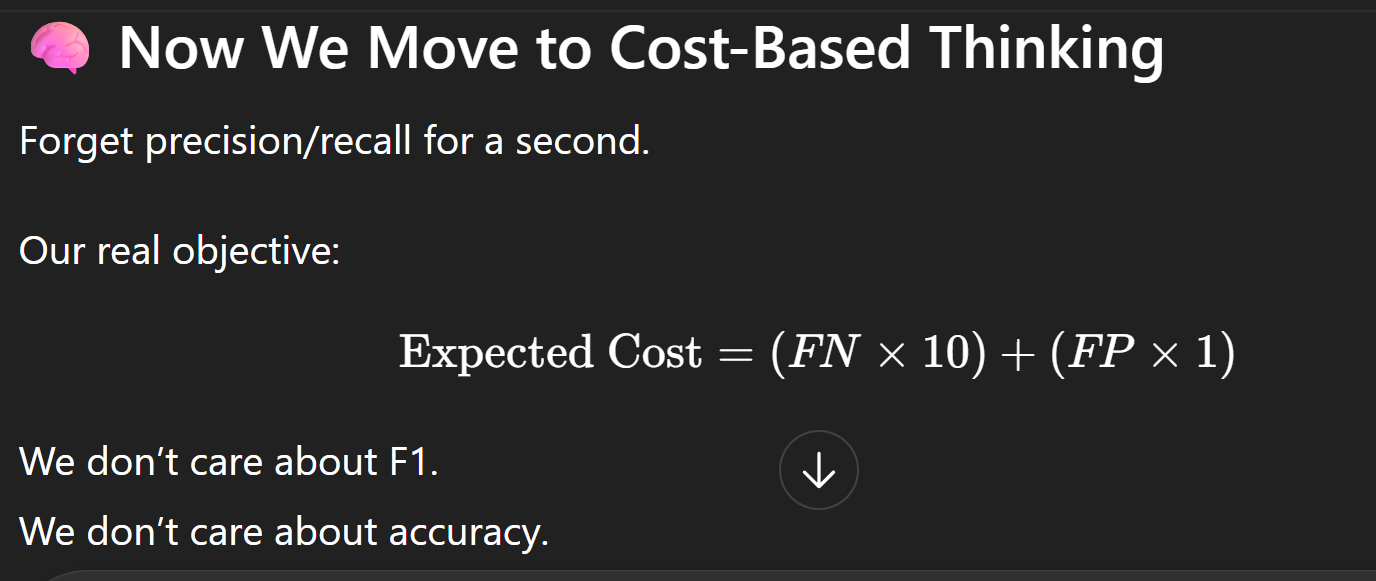

In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np

threshold = 0.5

test_pred = (test_probs>=threshold).astype(int)

cm = confusion_matrix(y_test,test_pred)
print('confusion_matrix:\n',cm)

tn , fp , fn , tp = cm.ravel()

expected_cost = (fn*10) + (fp*1)

print('false negative :',fn)
print('false positive :',fp)
print('expected cost :',expected_cost)

confusion_matrix:
 [[122  18]
 [ 34  26]]
false negative : 34
false positive : 18
expected cost : 358


# So:

FN = 34

FP = 18

Expected Cost = 358

Dumb baseline = 600

We already improved business loss by ~40%.

But remember:

Cost_FN = 10
Cost_FP = 1

So reducing FN matters A LOT more than reducing FP.

Right now we are still missing:
34 out of 60 defaulters.

That’s more than half.

Not ideal.

# Now Actually Run the Threshold Sweep

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.01,0.99,99)
costs = []

for i in thresholds:
    preds = (test_probs>=i).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_test,preds).ravel()
    cost = (fn*10) + (fp*1)
    costs.append(cost)

best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
best_cost = costs[best_idx]

print("Best Threshold:", best_threshold)
print("Minimum Expected Cost:", best_cost)


Best Threshold: 0.060000000000000005
Minimum Expected Cost: 124


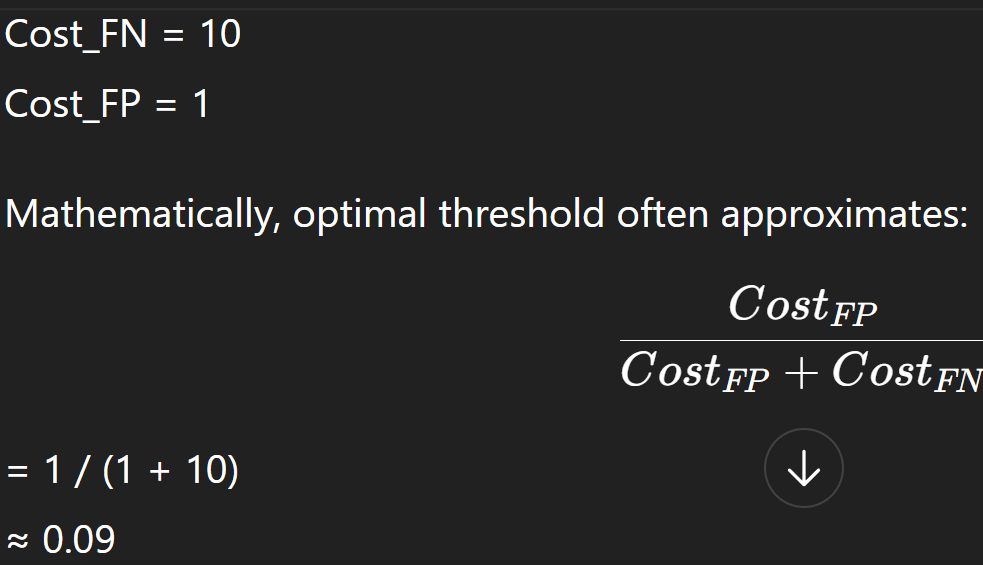

# 🚨 But Important Reality Check

Lower threshold means:

We are rejecting many more customers.

Now we must inspect:

How many FN left?

How many FP now?

Run confusion matrix at 0.06:

In [18]:
t = 0.06
preds = (test_probs > 0.06).astype(int)
cm = confusion_matrix(y_test,preds)
print('confusion matrix :\n',cm)

confusion matrix :
 [[ 26 114]
 [  1  59]]


# 🎯 Business Interpretation

We built a VERY conservative bank.

This bank says:

“If even 6% chance of default → reject.”

That dramatically reduces loan losses
But kills revenue opportunity.

# 🧠 Now You’re Facing Real Trade-Off

At threshold 0.5:

FN = 34

FP = 18

Cost = 358

At threshold 0.06:

FN = 1

FP = 114

Cost = 124

So financially 0.06 is better under 10:1 assumption.

But is it realistic?

Would a real bank reject 81% of good customers?

Probably not.

🔥 THIS is where modeling becomes strategy.

# We must ask:

Is our cost ratio realistic?

If cost_FN = 10 and cost_FP = 1
→ model behaves like this.

What if real loss ratio is 5:1?

Or 3:1?

Threshold would move.

# Understand Unit Economics

Suppose:

Average loan amount = ₹1,00,000

Interest rate = 10% per year

Average duration = 2 years

So expected profit from a fully repaid loan:

1
,
00
,
000
×
0.10
×
2
=
₹
20
,
000
1,00,000×0.10×2=₹20,000

So profit per good customer ≈ ₹20,000

Now suppose:

Default customer repays nothing
Bank recovers maybe 30% through collateral.

So:

Loss = ₹1,00,000 − ₹30,000 = ₹70,000

So loss per defaulter ≈ ₹70,000

# 📊 Realistic Cost Ratio

Loss from defaulter = 70,000
Lost profit from rejecting good = 20,000

Ratio ≈ 70,000 / 20,000 = 3.5 : 1

Not 10:1.

Now threshold would be very different.

# 🧠 This Changes Everything

Earlier:

Cost_FN = 10
Cost_FP = 1
→ threshold ≈ 0.06

Now:

Cost_FN = 3.5
Cost_FP = 1

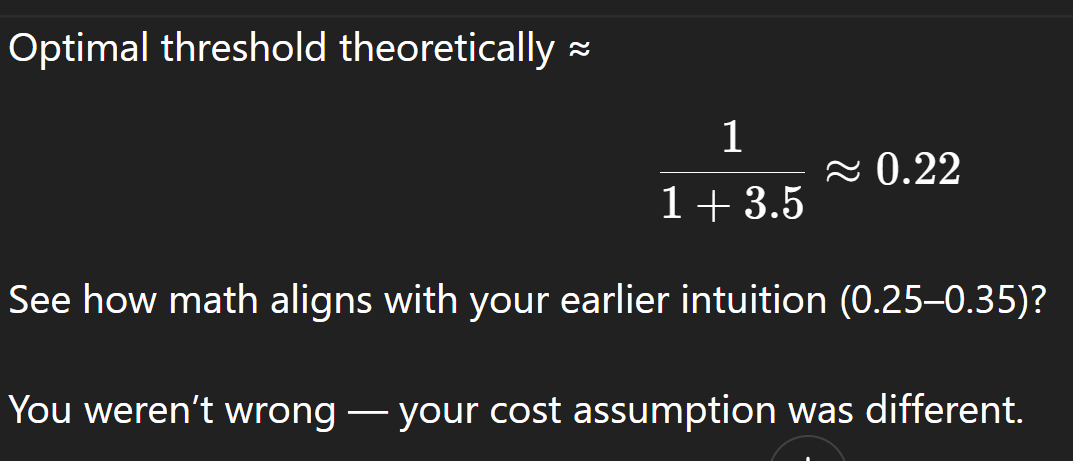

# 🧠 Now We Build Decision Profit Matrix
| Reality | Decision | Outcome          | Profit  |
| ------- | -------- | ---------------- | ------- |
| Good    | Approve  | Earn interest    | +20,000 |
| Good    | Reject   | Lose opportunity | 0       |
| Default | Approve  | Loan loss        | -70,000 |
| Default | Reject   | Avoid loss       | 0       |


# 🎯 Now We Replace “Expected Cost” With “Expected Profit”

Instead of:

### Cost = FN × 10 + FP × 1

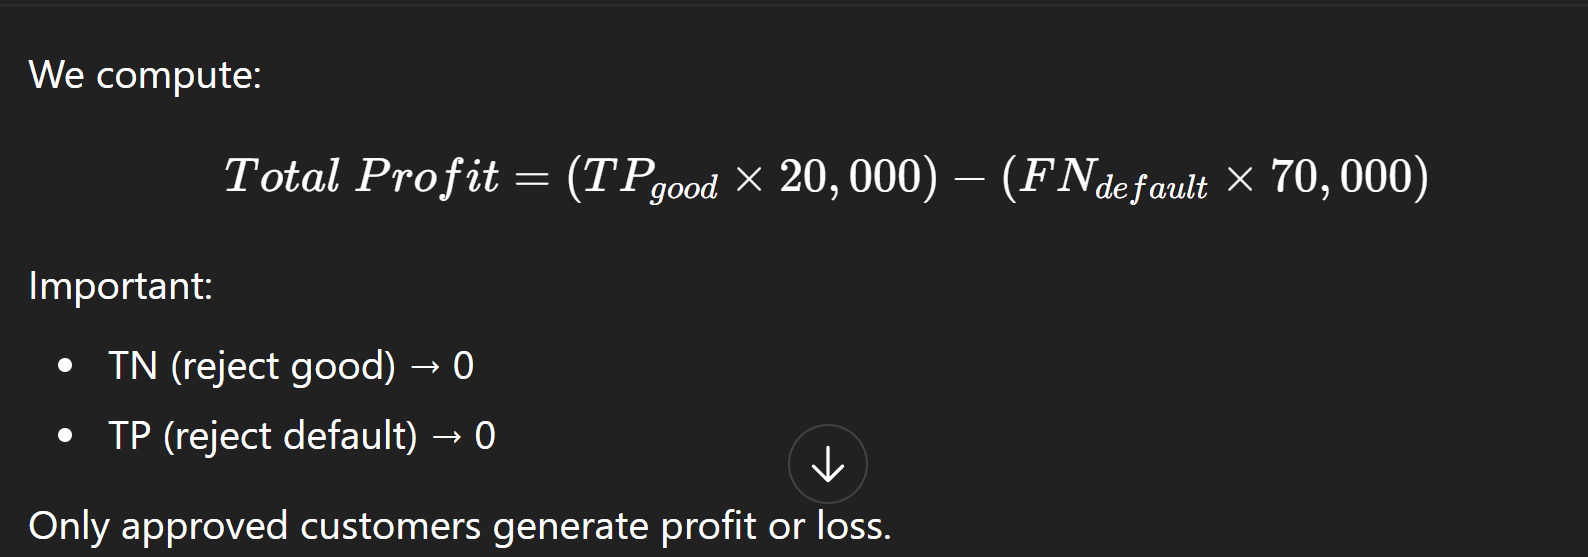

# 🚀 Now Implement Profit Sweep

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.01,0.99,99)
profits = []

for i in thresholds:
    preds = (test_probs>= i).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_test,preds).ravel()
    
    # Approving good customers = TN
    profit_good = tn*20000

    # Approving defaulters = FN
    loss_defaulter = fn*70000

    total_profit = profit_good - loss_defaulter

    profits.append(total_profit)

# np.argmax() means:
#👉 “Give me the index of the maximum value.”
best_idx = np.argmax(profits)
best_threshold = thresholds[best_idx]
best_profit = profits[best_idx]

print("Best Threshold:", best_threshold)
print("Maximum Expected Profit:", best_profit)

Best Threshold: 0.15000000000000002
Maximum Expected Profit: 680000


# What Might Be Wrong?

There are 3 possible concerns:

# 1️⃣ Assumptions too simplistic

We assumed:

Same loan amount for everyone

Same interest

Same recovery rate

Real banks use customer-level exposure.

# 2️⃣ No capital cost included

Banks also consider:

Cost of capital

Operational cost

Regulatory reserves

We ignored that.

# 3️⃣ We optimized on TEST set

This is important.

You just used the test set to find best threshold.

That means:
We tuned on test.

So 680,000 is optimistic.

Professional rule:
Threshold should be chosen using cross-validation on TRAIN.
Then evaluated once on TEST.

Right now, we slightly violated purity.

# Strategy Before Coding

We will:

1️⃣ Keep the SAME preprocessing pipeline
2️⃣ Replace LogisticRegression with XGBoost
3️⃣ Use cross-validation
4️⃣ Compare:

ROC-AUC

Profit (CV-based)

Stability

Only then decide.

No hype.
No blind switching.


In [20]:
from xgboost import XGBClassifier
xgb_model = Pipeline(steps=[
    ('preprocessor',preprocesser),
    ('classifier',XGBClassifier(
        n_estimators = 200,
        max_depth = 3,
        learning_rate = 0.05,
        subsample=0.8,
        colsample_bytree = 0.8,
        random_state = 42,
        eval_metric = 'logloss',
        use_label_encoder = False
    ))
]) 

In [21]:
cv_scores_xgb = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv = 5,
    scoring ='roc_auc'
)

print('XGBoost CV ROC-AUC: ',cv_scores_xgb)
print('Mean ROC-AUC: ',np.mean(cv_scores_xgb))

c:\Users\gupta\anaconda3\envs\envep\Lib\site-packages\xgboost\training.py:199: UserWarning: [08:15:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gupta\anaconda3\envs\envep\Lib\site-packages\xgboost\training.py:199: UserWarning: [08:15:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gupta\anaconda3\envs\envep\Lib\site-packages\xgboost\training.py:199: UserWarning: [08:15:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\gupta\anaconda3\envs\envep\Lib\site-packages\xgboost\training.py:199: UserWarning: [08:15:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_labe

XGBoost CV ROC-AUC:  [0.70889137 0.76804315 0.77641369 0.78348214 0.78887649]
Mean ROC-AUC:  0.7651413690476191


c:\Users\gupta\anaconda3\envs\envep\Lib\site-packages\xgboost\training.py:199: UserWarning: [08:15:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# 🎯 This Is Actually GOOD News

## Because now your project story becomes strong:

### We tested nonlinear boosting models as challenger. However, logistic regression outperformed in cross-validation and remained superior in interpretability and stability. Therefore, logistic regression was selected as the champion model.

# Now we must:

1️⃣ Do CV-based threshold tuning
2️⃣ Lock threshold
3️⃣ Evaluate once on test
4️⃣ Write business conclusion

This will finalize your model professionally.

In [22]:
from sklearn.model_selection import cross_val_predict
oof_probs = cross_val_predict(
      model,
      X_train,
      y_train,
      cv=5,
      method = 'predict_proba'
)[:,1]

In [23]:
profits = []

for i in thresholds:
    preds = (oof_probs>=i).astype(int)
    tn,fp,fn,tp  = confusion_matrix(y_train,preds).ravel()

    profit = tn*20000
    loss = fn*70000

    total_profit = profit - loss
    profits.append(total_profit)

best_idx = np.argmax(profits)
best_threshold = thresholds[best_idx]
best_profit = profits[best_idx]

print("Best Threshold (CV-based):", best_threshold)
print("Max CV Profit:", best_profit)

Best Threshold (CV-based): 0.18000000000000002
Max CV Profit: 3930000


# 🧠 Important Clarification About That 3,930,000

That profit number is computed over:

~800 training samples (combined across folds).

So it’s larger than your test profit earlier.

That’s normal.

We do NOT compare that number directly to test profit.

We only use it to find:

👉 Best threshold.

The threshold is what matters.

# 🎯 Now We Lock The System

We now have:

Champion model: Logistic Regression
Optimal threshold (CV-based): 0.18

Now we do the final step:

1️⃣ Fit model on full training set
2️⃣ Predict on test
3️⃣ Apply threshold = 0.18
4️⃣ Compute final profit

Test is touched only once.

This gives unbiased estimate.

In [25]:
model.fit(X_train,y_train)

test_probs = model.predict_proba(X_test)[:,1]

final_threshold = 0.18
preds = (test_probs>=final_threshold).astype(int)

tn , fp , fn , tp = confusion_matrix(y_test,preds).ravel()
print('Confusion_matrix \n:',confusion_matrix(y_test,preds))

profit = tn*20000
loss = fn*70000

total_profit = profit - loss

print('total_profit :',total_profit)


Confusion_matrix 
: [[69 71]
 [13 47]]
total_profit : 470000


| Reality     | Approve (0) | Reject (1) |
| ----------- | ----------- | ---------- |
| Good (0)    | 69 (TN)     | 71 (FP)    |
| Default (1) | 13 (FN)     | 47 (TP)    |


# Extract Coefficients Properly

In [27]:
import pandas as pd
import numpy as np

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

coefficients = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature':feature_names,
    "Coefficients":coefficients
})

coef_df['Abs_Coefficients'] = np.abs(coef_df['Coefficients'])

coef_df = coef_df.sort_values(by='Abs_Coefficients',ascending=False)
coef_df.head(15)

,Feature,Coefficients,Abs_Coefficients
8,cat__Account_Balance_4,-1.651585,1.651585
13,cat__Purpose_1,-1.543362,1.543362
24,cat__Value_Savings_Stocks_4,-1.167446,1.167446
12,cat__Payment_Status_of_Previous_Credit_4,-1.133643,1.133643
25,cat__Value_Savings_Stocks_5,-0.992041,0.992041
49,cat__Foreign_Worker_2,-0.989222,0.989222
7,cat__Account_Balance_3,-0.929235,0.929235
21,cat__Purpose_10,-0.784990,0.784990
11,cat__Payment_Status_of_Previous_Credit_3,-0.734316,0.734316
34,cat__Guarantors_3,-0.726250,0.726250


# First important reminder:

Your target = **Default = 1**

So:

* Negative coefficient → decreases probability of default
* Positive coefficient → increases probability of default

---

# 🧠 Strongest Risk-Reducing Features (Large Negative Coefficients)

Let’s interpret the top ones.

---

## 1️⃣ Account_Balance_4 (−1.65)

Very strong negative.

This likely represents:
“High checking account balance”

Interpretation:

> Customers with high account balances have significantly lower odds of default.

Economically intuitive.

Exponentiate to understand strength:

[
e^{-1.65} ≈ 0.19
]

That means odds of default are reduced by ~81%.

That’s huge.

Very defendable.

---

## 2️⃣ Purpose_1 (−1.54)

Certain loan purposes are safer.

If Purpose_1 corresponds to something like:
Car loan / education / business investment

Interpretation:

> Certain structured loan purposes are associated with materially lower default risk.

Purpose matters in underwriting.

Logical.

---

## 3️⃣ Value_Savings_Stocks_4 (−1.16)

High savings category.

Interpretation:

> Customers with larger savings reserves exhibit significantly reduced default risk.

Financial cushion → lower risk.

Very intuitive.

---

## 4️⃣ Payment_Status_of_Previous_Credit_4 (−1.13)

Good previous repayment history.

Interpretation:

> Strong past repayment performance is a powerful predictor of lower future default.

Classic credit scoring principle.

This is exactly what traditional credit models rely on.

---

## 5️⃣ Foreign_Worker_2 (−0.99)

Now this one is interesting.

You must be careful here.

This variable might encode:

1 = No
2 = Yes

Depending on encoding.

If coefficient is negative, that category reduces default risk.

But in interviews, you must be cautious:

> Certain demographic indicators may correlate with repayment stability; however, such variables require fairness review before deployment.

Never blindly celebrate demographic signals.

That shows regulatory awareness.

---

# 🧠 Now Look at the Positive Coefficient

You showed one:

Most_valuable_available_asset_4 → +0.69

Interpretation:

> Certain asset categories are associated with increased default risk.

That might correspond to:

No asset / low collateral class.

Check documentation to interpret properly.

---

# 🎯 Big Insight

Notice something powerful:

Top features are:

* Account balance
* Savings
* Previous repayment
* Employment length
* Guarantors

These are classic credit underwriting variables.

This confirms:

Logistic regression is capturing meaningful financial structure.

No weird interactions.
No irrational signals.

That’s exactly what we want.

---

# 🏦 Now How You Explain This In Interview

You say:

> The strongest risk-reducing features were high account balance, strong previous repayment history, and substantial savings. These align with traditional credit underwriting logic and confirm that the model is economically coherent rather than purely statistical.

That sounds professional.

---

# 🧠 Now I Challenge You

Look at:

Length_of_current_employment_4 (−0.67)

Why would employment length reduce default risk?

And why might that be monotonic?

Answer that like a risk analyst, not a student.


In [36]:
df['Length_of_current_employment'].value_counts().sort_index(ascending=True)

Length_of_current_employment
1     62
2    172
3    339
4    174
5    253
Name: count, dtype: int64

In [37]:
grouped = df.groupby('Length_of_current_employment')['default'].mean()
grouped

Length_of_current_employment
1    0.370968
2    0.406977
3    0.306785
4    0.224138
5    0.252964
Name: default, dtype: float64

# 🧠 Now Why Does It Feel Suspicious?

Because it’s not monotonic.

You expected:

1 < 2 < 3 < 4 < 5 (steady improvement)

But instead:

4 is safest
5 slightly worse than 4
3 worse
2 worst

So pattern is not smooth.

That’s what triggered your instinct.

Good instinct.

# 🏦 Why Might This Happen Economically?

In German Credit dataset, employment categories usually mean:

1 → unemployed
2 → < 1 year
3 → 1–4 years
4 → 4–7 years
5 → > 7 years

Now think economically:

People with 4–7 years:

Stable

Established

Mid-career

People with >7 years:

Could include older individuals nearing retirement

Might include stagnated income groups

So risk might not strictly decrease forever.

Stability might peak in mid-career.

That is plausible.